Imports

In [1]:
import os
import torch

# Patch torch.load to set weights_only=False by default (for PyTorch 2.6+)
_original_load = torch.load
_patching = False

def _patched_load(*args, **kwargs):
    global _patching
    if _patching:
        return _original_load(*args, **kwargs)
    _patching = True
    try:
        if 'weights_only' not in kwargs:
            kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)
    finally:
        _patching = False

torch.load = _patched_load

from ultralytics import YOLO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import cv2

Load the model and run the inference



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 21 persons, 73.0ms
video 1/1 (frame 2/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 21 persons, 46.0ms
video 1/1 (frame 3/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 22 persons, 49.0ms
video 1/1 (frame 4/750) c:\Object_Detection_Projects\Soccer_AI\input-videos\08fd33_4.mp4: 384x640 23 person

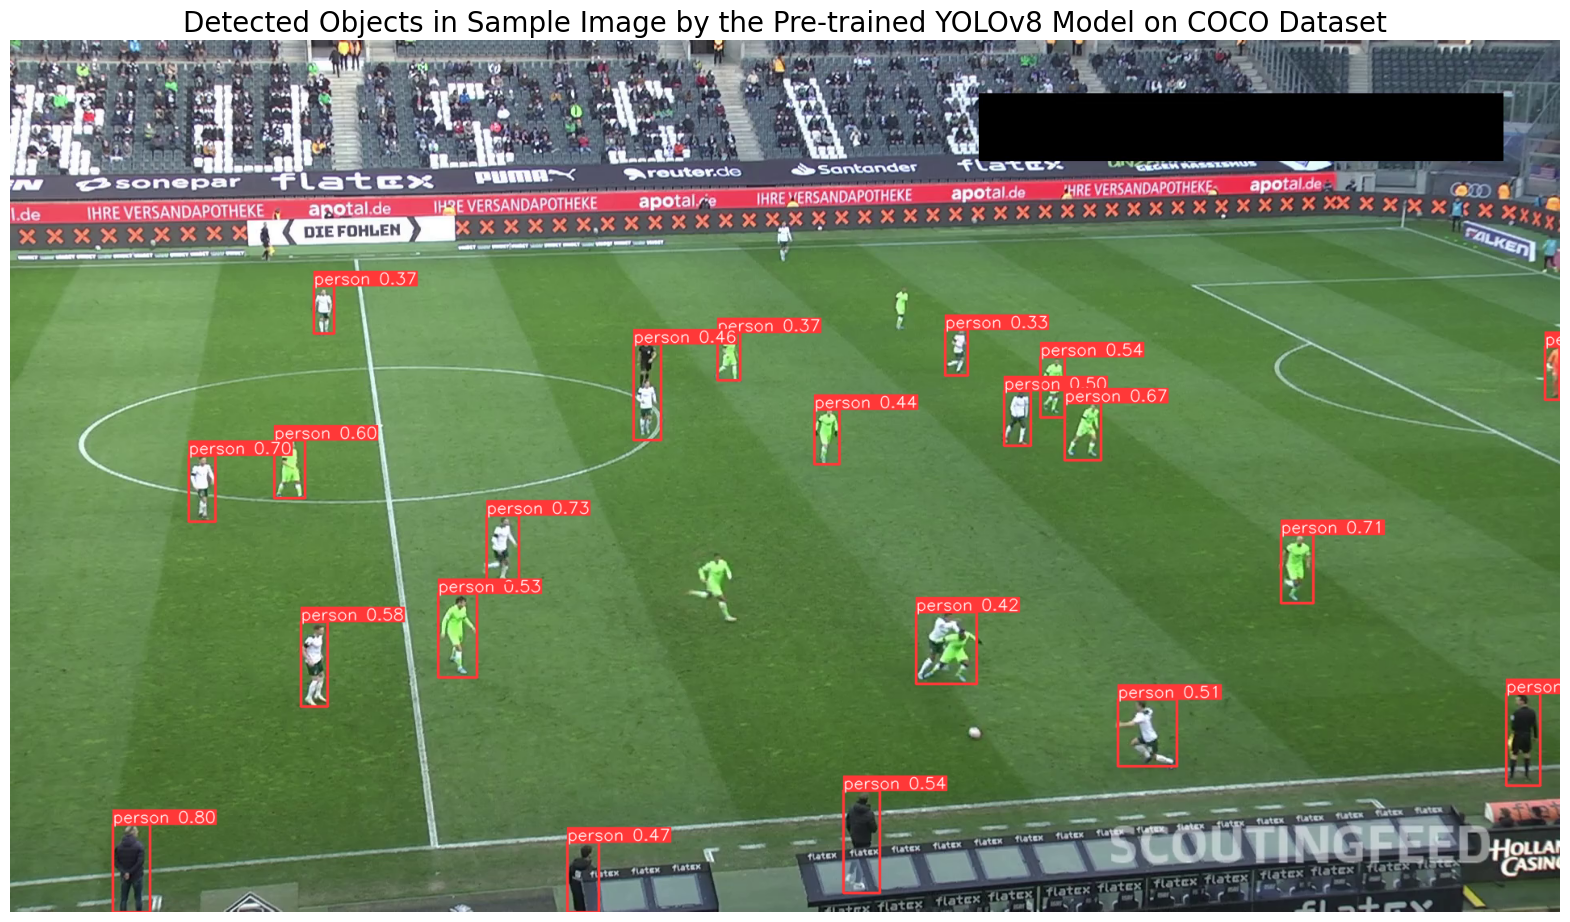

In [ ]:
model = YOLO("yolov8n.pt")

# Run batched inference on a list of images
results = model.predict("input-videos/08fd33_4.mp4", stream=false)  # return a list of Results objects
os.makedirs("inference_results", exist_ok=True)

# Annotate and convert image to numpy array
sample_image = results[0].plot(line_width=2)

# Convert the color of the image from BGR to RGB for correct color representation in matplotlib
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Display annotated image
plt.figure(figsize=(20,15))
plt.imshow(sample_image)
plt.title('Detected Objects in Sample Image by the Pre-trained YOLOv8 Model on COCO Dataset', fontsize=20)
plt.axis('off')
plt.show() # save to disk